In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.primitives import SamplerV2 as Sampler #new version
import matplotlib.pyplot as plt
import numpy as np
import scipy

- Let's project a physical system to qubits!  
- Concept of quantum criticality (magnetic phase, while increasing T the phase is destroyed) -> quantum fluctuations
- Condensed matter physics
- We are in a very low temperature, then we analyze another parameter of the material e.g. pressure
- Transverse Field Ising Chain System (they try to interact with each other in zero T)
- GS of the H is the most democtratic state

H = Hzz + Hx

Magnetization m^ = 1/N_s sum(si)^2

Start with ordered state phi0 = |000...>
Then I want to evolve in time and find a find dependent mangentization
phiT = e^(-itH)phi0

## Task 1

In [3]:
# define parameters

h = np.pi/8
J = np.pi/4
dt = 1

thetaZ = -2*J*dt
thetaH = -2*h*dt

In [109]:
def one_step(qc,n = 5):
    for i in range(n-1):
        qc.rz(thetaZ, i)
        qc.rz(thetaZ, i+1)
        qc.cz(i, i+1)
        qc.barrier()
    
    qc.rx(thetaH, range(n))
    return qc

In [159]:
Niter = 20
nshots = 1000
circuits = []

for n in range(Niter):
    qc = QuantumCircuit(5)
    for shot in range(n):
        one_step(qc)
    qc.measure_all()
    circuits.append(qc)

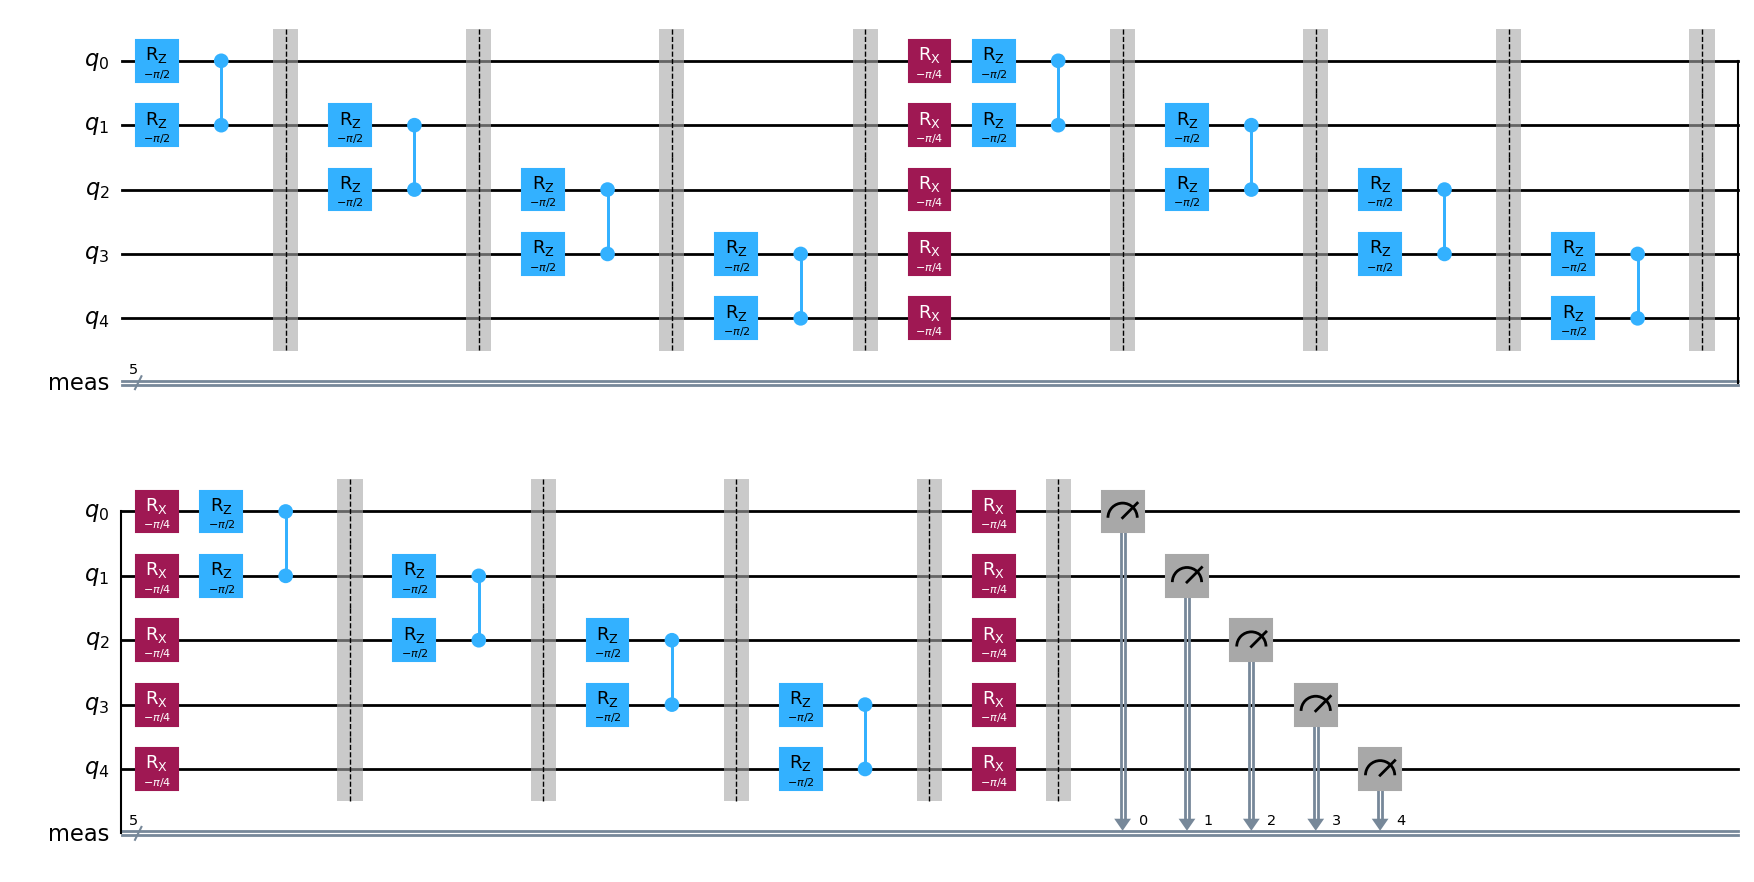

In [160]:
fig = circuits[3].draw("mpl")
fig

In [162]:
def parse_counts(counts, nshots = 1000, nspin = 5):
    mag = 0
    for out, count in counts.items():
        values = [1 if bit == '0' else -1 for bit in list(out)]
        mag+= np.sum(values) * count/ (nshots * nspin)
    return mag


In [163]:
job = Sampler().run(circuits, shots = nshots)
results = job.result()
mag = []
for n, result in enumerate(results):
    counts = result.data.meas.get_counts()
    mag.append(parse_counts(counts))

Text(0, 0.5, 'Magnetization')

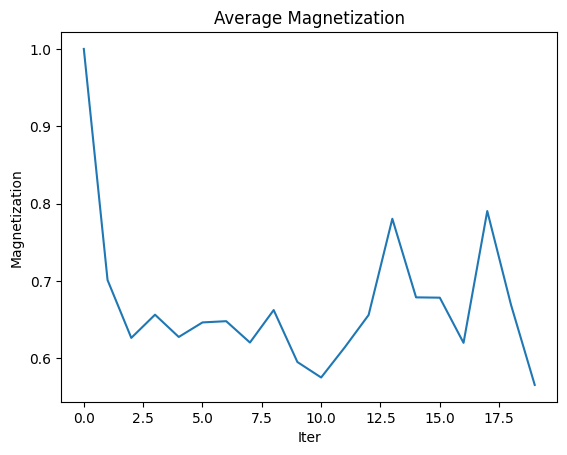

In [164]:
plt.plot(mag)
plt.title("Average Magnetization")
plt.xlabel("Iter")
plt.ylabel("Magnetization")


## Task 2

In [165]:
def full_matrix(s, N):

    operators = []
    eye = np.eye(2)
    
    for i in range(N):
        if i == 0:
            m = s
        else:
            m = eye
            
        for j in range(1, N):
            if j == i:
                m = np.kron(m, s)
            else:
                m = np.kron(m, eye)
        
        operators.append(m)
        
    return operators

In [166]:
# define Pauli matrices

basic_sz = np.array([[1, 0], [0, -1]])
basic_sx = np.array([[0, 1], [1, 0]])

sx = full_matrix(basic_sx, 5)
sz = full_matrix(basic_sz, 5)

In [167]:
def hamiltonianZZ(J = J, sz = sz, N = 5):
    H = 0
    for i in range(N-1):
        H += -J * sz[i] @ sz[i+1]
    return H

In [168]:
def hamiltonianX(h = h, sx = sx, N = 5):
    H = 0
    for i in range(N):
        H += -h * sx[i]
    return H

In [169]:
Uzz = scipy.linalg.expm(-1j* hamiltonianZZ()*dt)
Ux = scipy.linalg.expm(-1j* hamiltonianX()*dt)

In [170]:
N = 5  
up = np.array([1, 0])  

psi0 = up
for _ in range(N - 1):
    psi0 = np.kron(psi0, up)

In [171]:
OpMag = 0
for i in range(N):
    OpMag += 1/N * sz[i]

mag2 = []
psi_current = psi0.copy() 


U_step = Ux @ Uzz 

for i in range(Niter):

    val = np.real(psi_current.conj().T @ OpMag @ psi_current)
    mag2.append(val)
    psi_current = U_step @ psi_current

Text(0, 0.5, 'Magnetization')

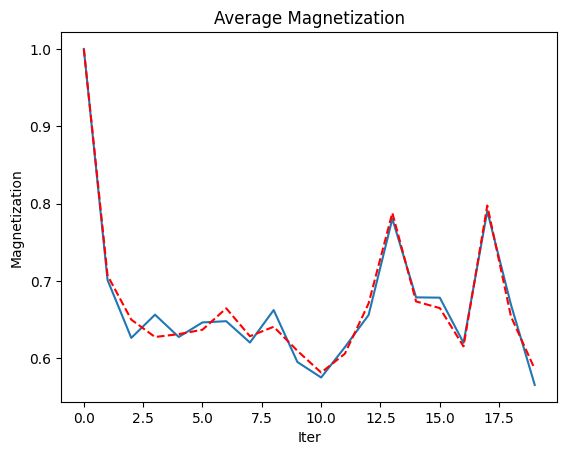

In [173]:
plt.plot(mag)
plt.plot(mag2, color = 'red', linestyle = '--')

plt.title("Average Magnetization")
plt.xlabel("Iter")
plt.ylabel("Magnetization")